In [3]:
from mpl_toolkits import mplot3d
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

# Generate the Data

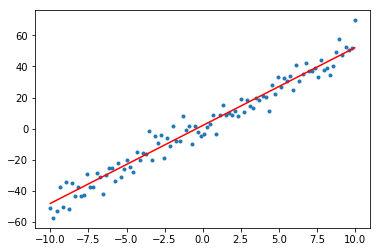

In [13]:
# generate the data
def realFunc(x1):
    return 2 + 5*x1 
    #return 2 + 5*x1**2

N = 100
noise = 5 #40
x1 = np.linspace(-10.0,10.0,N) 
t1 = np.random.normal(realFunc(x1),noise) # target

#plot the data along the real model
plt.plot(x1,t1,'.')
plt.plot(x1,realFunc(x1),'r')
# generate model solution



In [14]:
#X.shape

In [15]:
def outSGD(J, w, tme, name='SGD',ax=None, plotJ=True, printw=True):        
    if plotJ:
        ax = ax or plt.gca()
        ax.plot(J[1:],'.b')
    if printw:
        print("y ={}+ {}x1".format(w[0],w[1]), " {} took:    {} seconds ".format(name, tme))


In [16]:
def SGD(w,X,t):                                      # vectorised
    N    = len(t)                                    # number of data points
    grad = -(1.0/(  N))*X.T*(t - X*w)                # gradient
    J    =  (1.0/(2*N))*    (t - X*w).T * (t - X*w)  # the loss
    return grad, J

In [27]:
def SGD_Batch_Learn(X1,t, eta=0.01, maxep=100, decay=0.98): #,  **kwargs): # vectorised
    start_time = time.time()
    # data perperation......................................
    x0= np.ones(len(X1))     
    X = np.vstack((x0,X1)).T      # add dummy feature

    X = np.matrix(X)
    t = np.matrix(t).T

    w_all = []        
    w = np.ones((2,1))                    # initialise w
    J = np.zeros((maxep))                 # the loss in each epoch
    
    for ep in range(maxep):               # epochs
        grad, J[ep] = SGD(w,X,t)
        w = w -eta*grad
        eta *= decay
        w_all.append(w)

    tme = time.time() - start_time
    return w, J, tme, w_all 



16.528128003075157
y =[[1.06306623]]+ [[4.9990621]]x1  SGD_vectrzd took:    0.0009982585906982422 seconds 


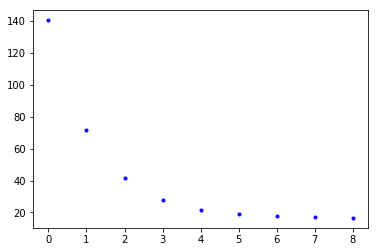

In [28]:
w,J,tme,_ = SGD_Batch_Learn(x1,t1,eta=0.01,maxep=10) #, eta, maxep, decay,ax2)
print((J[-1]))
outSGD(J, w, tme, 'SGD_vectrzd')

# Two Layers Neural Network with Sigmoid and Linear Activaiton Functions Respectively

(100, 2)


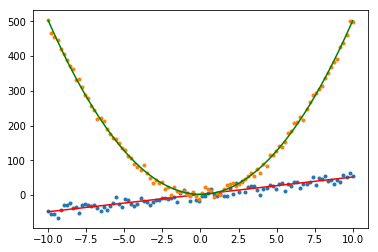

In [92]:
# generate the data
def realFunc(x1, typ='2'):
    if typ=='1':        return 2 + 5*x1 
    if typ=='2':        return 2 + 5*x1**2

N = 100
noise = 10 #40
x1 = np.linspace(-10.0,10.0,N) 
t1 = np.random.normal(realFunc(x1,'1'),noise) # target

x2 = np.linspace(-10.0,10.0,N) 
t2 = np.random.normal(realFunc(x1,'2'),noise) # target

#plot the data along the real model
plt.plot(x1,t1,'.')
plt.plot(x1,realFunc(x1,'1'),'r')

plt.plot(x2,t2,'.')
plt.plot(x2,realFunc(x2,'2'),'g')

# now combine both data in one dataset with multiple outputs
T = np.vstack((t1,t2)).T
X = np.vstack((x1,x2)).T
print(X.shape)

In [93]:
def getPhi(X,W1):
    N = len(X)
    Phi = sig(np.dot(X,W1))
    
    phi0= np.ones((N,1))
    Phi = np.hstack((phi0,Phi))   # add dummy feature
    return Phi

def getY(Phi,W2):
    N = len(Phi)
    Y = np.dot(Phi,W2)
    return Y

In [33]:
# toys data................................................................................................
# W1 = np.array([[.1 , .2, .3 ], [.4 , .5 , .6], [.7 , .8, .9], [.10, .11, .12]])   # hidden layer
# W2 = np.array([[.1 , .2 ], [.2 , .4], [.3 , .6]])                                 # output layer

# X = np.array([[1 , 2,  3, 4 ], [5 , 6 , 7, 8], [9 , 10, 11, 12], [13, 14, 15, 16], [17, 18, 19, 20]])*0.2
# T = np.array([[1,2],           [3,4],          [5,6],            [7,8],            [9,10]])

# build a two layer networks...............................................................................

def sig(x):
    return 1/(1+np.exp(-x))

def predict(X,T, W1,W2):
    N   = len(X)
    Phi = sig(np.dot(X,W1))

    phi0= np.ones((N,1))
    Phi = np.hstack((phi0,Phi))   # add dummy feature
    
    Y   = np.dot(Phi,W2)
    Err = T-Y
    mse = (1.0/(2*N))*sum(sum(Err**2))
    return Y, Phi, mse #, np.sqrt(mse)

def fit(X,T, eta, epochs, hdim, lmbda):
    N    = X.shape[0]              # size of the training set
    
    x0   = np.ones((N,1))
    X    = np.hstack((x0,X))       # add dummy feature

    odim = T.shape[1]              # number of output neurons
    idim = X.shape[1]              # number of input  neurons
    hdim = hdim                    # number of hidden neurons or number of features
    
    # initialise the weights
    W1 = np.zeros((idim,hdim))     # hidden layer
    W2 = np.zeros((hdim+1,odim))   # output layer

    mse  = np.zeros((epochs,1))

    for epoch in range(epochs):
        Y, Phi, mse[epoch] = predict(X, T, W1, W2)    
        
        Err = T-Y
        W2[1:,:]= (1-lmbda)*W2[1:,:] # do not regularise the bias
        
        W2      = W2 + (1.0/N)*eta*np.dot(Phi.T,Err)   # adjust the ouput weights W2 as in the GD method: linear activaiton function 
        Phi1_   = Phi[:,1:]                       # execlude the dummy feature because it cannot contribute to hidden wights W1 update        
        PhiGrad = np.multiply(Phi1_, 1-Phi1_)     # now probagate the error back to hidden weights W1
        
        for j in range(odim):
            #print('updating hidden layer according to {} output neuron'.format(j))
            Errj = Err[:,j].reshape(N,1)
            W1[1:,:]= (1-lmbda)*W1[1:,:] # do not regularise the bias
            W1   = W1 + (1.0/N)*eta*np.dot(X.T,PhiGrad*Errj)*W2[1:,j]
        
        eta *= 0.98

    return W1, W2, mse


final mse =  [105.45228551]


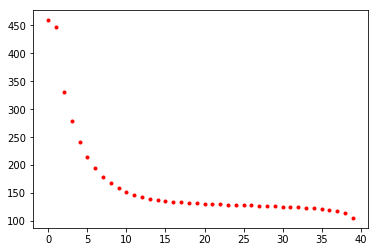

In [41]:
def trainNetwork(X,T):

    eta    = 0.5
    
    lmbda  = 0.0
    epochs = 40
    hdim   = 2
    W1, W2, mse = fit(X, T, eta, epochs, hdim, lmbda)
    plt.plot(mse,'.r')
    print('final mse = ', mse[-1])
    
#trainNetwork(X,T)
trainNetwork(x1.reshape((N,1)),t1.reshape((N,1)))

16.528128003075157
y =[[1.06306623]]+ [[4.9990621]]x1  SGD_vectrzd took:    0.0019943714141845703 seconds 


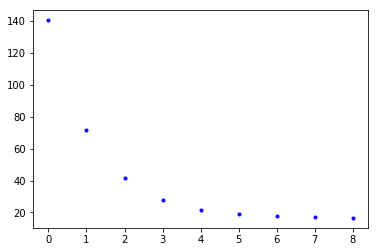

In [29]:
w,J,tme,_ = SGD_Batch_Learn(x1,t1,eta=0.01,maxep=10) #, eta, maxep, decay,ax2)
print((J[-1]))
outSGD(J, w, tme, 'SGD_vectrzd')